# Analisis Exploratorio de Datos

- Base de datos utilizada: excel con datos de pacientes datada de 2022

## Parte 0: setup y limpieza

### Imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import geopandas as gpd
import folium
from scipy import stats
from shapely.geometry import LineString
import contextily as ctx

import sys
sys.path.append("../scripts")  # agregás la carpeta donde está bases.py
import bases

#### 0.1. Carga de datos

In [11]:
df_pacientes = pd.read_excel("..\data\pacientes.xlsx")
print("Cantidad de registros:", len(df_pacientes))
df_pacientes.head()

# ------------------------------------------------------------
# ------------------------------------------------------------

hosp_coord = pd.read_csv("..\data\hospitales_coordenadas.csv")
print("Cantidad de registros:", len(hosp_coord))
hosp_coord.head()

Cantidad de registros: 7400
Cantidad de registros: 14


,Nombre Hospital,Latitud,Longitud
0,UPA 17 - QU,-34.736891,-58.329612
1,Oñativia,-34.783752,-58.352108
2,UPA 10 - BE,-34.799818,-58.174445
3,Lucio Meléndez,-34.812009,-58.386263
4,El Cruce,-34.772094,-58.270611


#### 0.2. Limpieza basica

In [12]:
# Limpiar Id inválidos
df_pacientes = df_pacientes[df_pacientes["Id"].astype(str).str.match(r"[A-Za-z0-9]+")]

# Normalizar nombres de hospitales
df_pacientes["Nombre Hospital"] = (
    df_pacientes["Nombre Hospital"]
    .str.strip()
    .str.upper()
)

# Convertir fechas
date_cols = ["Fecha inicio", "Fecha egreso", "Última actualización"]
for c in date_cols: df_pacientes[c] = pd.to_datetime(df_pacientes[c], errors="coerce")

# Duración de internacion
df_pacientes["Duracion días"] = (df_pacientes["Fecha egreso"] - df_pacientes["Fecha inicio"]).dt.days

# Valores nulos
print(df_pacientes.isna().sum())

#print("A continuacion, presentamos los motivos de egreso para cada instancia del dataframe")
#print(df["Motivo"].value_counts())


Id Hospital                      0
Nombre Hospital                  0
Id                               0
Fecha inicio                  1382
Estado al ingreso                0
Tipo al ingreso                  0
Último estado                    0
Último tipo                      0
Sexo                          1466
Edad                          1518
Nivel riesgo clínico          1924
Nivel riesgo social           2034
Enfermedades preexistentes    3174
Motivo                         506
Operación                      506
Fecha egreso                  1844
Última actualización             0
Duracion días                 2151
dtype: int64


#### Construccion de 'traslados' y 'G' (red) a partir del dataset

Estos hospitales no están en hosp_coords y se ignoraron: {'MÓDULO HOSPITALARIO  9 - AB', 'LUCIO MELÉNDEZ', 'OÑATIVIA', 'IRIARTE', 'EL CRUCE', 'EVITA PUEBLO', 'MÓDULO HOSPITALARIO 10 - QU', 'MÓDULO HOSPITALARIO 11- FV', 'MI PUEBLO'}
No hay aristas para mostrar


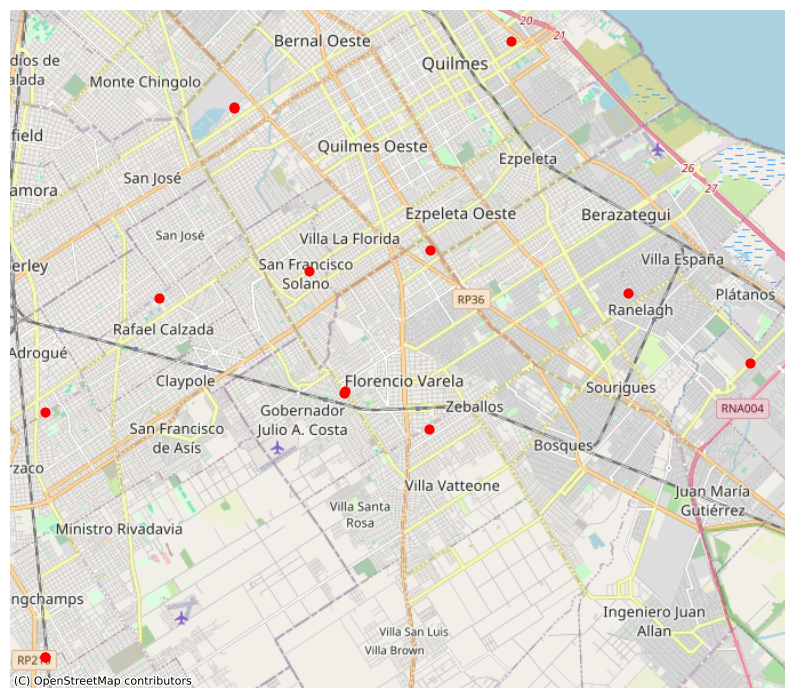

In [13]:
# reconstruir traslados usando la función de BASES
df_traslados = bases.reconstruir_traslados(df_pacientes)

# ver los primeros registros
# df_traslados.head()

# generar red para todo el período
G, edges = bases.generar_red(df_traslados, fecha_inicio="2020-06-01", fecha_fin="2020-10-31")

# ahora G es el grafo de networkx
fig, ax = bases.plot_red_con_mapa(G, hosp_coord)
plt.show()


Estos hospitales no están en hosp_coords y se ignoraron: {'MÓDULO HOSPITALARIO  9 - AB', 'LUCIO MELÉNDEZ', 'OÑATIVIA', 'IRIARTE', 'EL CRUCE', 'EVITA PUEBLO', 'MÓDULO HOSPITALARIO 10 - QU', 'MÓDULO HOSPITALARIO 11- FV', 'MI PUEBLO'}
No hay aristas para mostrar


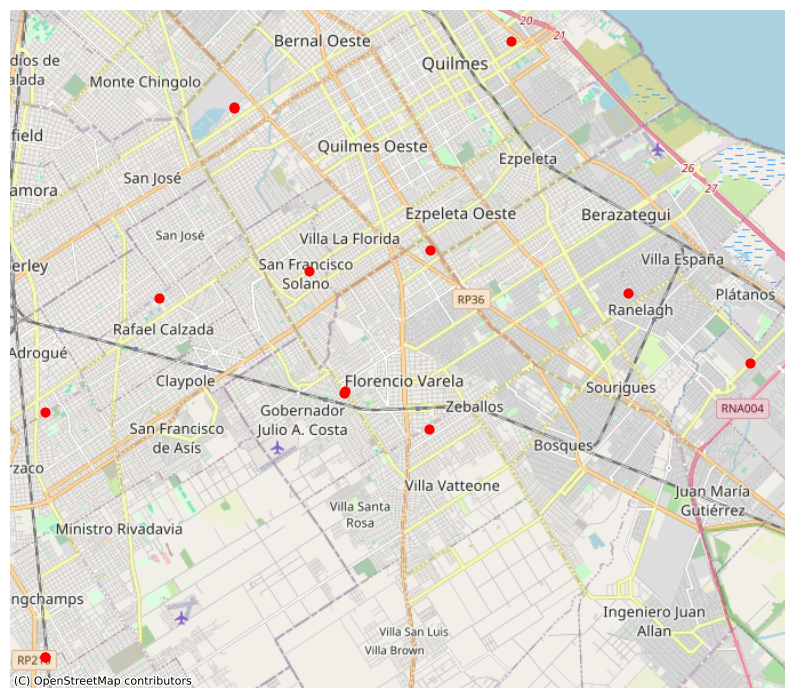

In [14]:
# generar red para todo el período
G, edges = bases.generar_red(df_traslados, fecha_inicio="2020-06-01", fecha_fin="2020-10-31")

# ahora G es el grafo de networkx
fig, ax = bases.plot_red_con_mapa(G, hosp_coord)
plt.show()


## Parte 1: Analisis Exploratorio de los datos

## 1.1. Contexto Geográfico

In [15]:
hosp_coords = pd.read_csv("..\data\hospitales_coordenadas.csv")

hosp_coords["Latitud"] = (
    hosp_coords["Latitud"].astype(str)
    .astype(float)
)

hosp_coords["Longitud"] = (
    hosp_coords["Longitud"].astype(str)
    .str.replace(",", ".")
    .astype(float)
)

hosp_coords["Nombre Hospital"] = hosp_coords["Nombre Hospital"].str.strip()

Mapa de hospitales

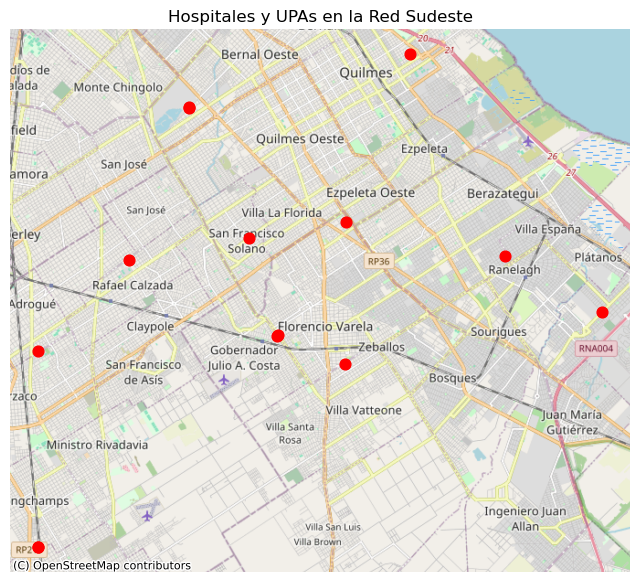

In [16]:
gdf_hosp = gpd.GeoDataFrame(
    hosp_coords,
    geometry=gpd.points_from_xy(
        hosp_coords["Longitud"],
        hosp_coords["Latitud"]
    ),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(8,8))

gdf_hosp.to_crs(epsg=3857).plot(
    ax=ax,
    color="red",
    markersize=60
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.title("Hospitales y UPAs en la Red Sudeste")
plt.axis("off")
plt.show()

#### Mapa de la Red Sudeste: Uso de geopandas para graficar los polígonos de Quilmes (QU), Almirante Brown (AB), Florencio Varela (FV) y Berazategui (BE). Superponer los puntos (lat/lon) de los hospitales y UPAs.

In [ ]:
municipios = gpd.read_file("municipios_sudeste.shp")

municipios = municipios[
    municipios["nombre"].isin([
        "QUILMES",
        "ALMIRANTE BROWN",
        "FLORENCIO VARELA",
        "BERAZATEGUI"
    ])
]

fig, ax = plt.subplots(figsize=(8,8))

municipios.to_crs(epsg=3857).plot(
    ax=ax,
    alpha=0.3,
    edgecolor="black"
)

gdf_hosp.to_crs(epsg=3857).plot(
    ax=ax,
    color="red",
    markersize=60
)

ctx.add_basemap(ax)

plt.title("Red Sudeste y hospitales")
plt.axis("off")
plt.show()

### 1.1.2. Matriz de Distancias: Tabla o heatmap con las distancias en km entre nodos (necesario para validar luego la "distancia recorrida").

Convertimos a coordenadas métricas.

In [ ]:
gdf_hosp_m = gdf_hosp.to_crs(epsg=3857)

Calcular matriz

In [ ]:
n = len(gdf_hosp_m)

dist_matrix = pd.DataFrame(
    np.zeros((n,n)),
    index=gdf_hosp_m["Nombre Hospital"],
    columns=gdf_hosp_m["Nombre Hospital"]
)

for i, row_i in gdf_hosp_m.iterrows():
    
    for j, row_j in gdf_hosp_m.iterrows():
        
        dist = row_i.geometry.distance(row_j.geometry) / 1000
        
        dist_matrix.loc[
            row_i["Nombre Hospital"],
            row_j["Nombre Hospital"]
        ] = dist

Ver matriz

In [ ]:
dist_matrix.round(2).head()

Heatmap de distancias

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    dist_matrix,
    cmap="viridis"
)

plt.title("Distancia entre hospitales (km)")
plt.show()

### 1.1.4. Distribución de tiempos entre hospitales

In [ ]:
dias = traslados["dias_entre_hospitales"]

plt.figure(figsize=(8,5))

dias.hist(bins=20)

plt.title("Distribución de días entre hospitales")
plt.xlabel("Días")
plt.ylabel("Cantidad")

plt.show()

### 1.1.5. Chequeo de errores (tiempos negativos)

In [ ]:
negativos = traslados[traslados["dias_entre_hospitales"] < 0]

print("Cantidad negativos:", len(negativos))

Ver ejemplos

In [ ]:
negativos[[
    "Id",
    "Nombre Hospital",
    "Hospital siguiente",
    "Fecha egreso",
    "Fecha ingreso siguiente",
    "dias_entre_hospitales"
]].head(10)

### 1.1.6. Construcción de red hospitalaria

In [ ]:
G_periodo, edges_periodo = bases.generar_red(
    traslados,
    "2020-06-01",
    "2020-10-31"
)

Metricas basicas

In [ ]:
print("Nodos:", G_periodo.number_of_nodes())
print("Aristas:", G_periodo.number_of_edges())

print("Densidad:", nx.density(G_periodo))
print("Componentes débiles:", nx.number_weakly_connected_components(G_periodo))

Hospitales que más reciben pacientes

In [ ]:
in_strength = dict(G_periodo.in_degree(weight="weight"))

sorted(
    in_strength.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

Hospitales que más derivan pacientes

In [ ]:
out_strength = dict(G_periodo.out_degree(weight="weight"))

sorted(
    out_strength.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

Intermediarios de la red

In [ ]:
bet = nx.betweenness_centrality(G_periodo, weight="weight")

sorted(
    bet.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

### 1.1.7. Visualización de la red

In [ ]:
fig, ax = bases.plot_red_con_mapa(G_periodo, hosp_coords)

m = bases.plot_red_interactiva(G_periodo, hosp_coords)

m

## 1.2. Métricas de Traslados (Flujo General)

In [ ]:
traslados = bases.reconstruir_traslados(df_pacientes)

print("Traslados confirmados:", len(traslados))

#### 1.2.1. Volúmenes Totales

In [ ]:
# total de admisiones
total_admisiones = len(df_pacientes)

# total de traslados detectados
total_traslados = len(traslados)

porcentaje_traslados = total_traslados / total_admisiones * 100

print("Total admisiones:", total_admisiones)
print("Total traslados:", total_traslados)
print("Porcentaje de admisiones que terminan en traslado:", round(porcentaje_traslados,2), "%")

#### 1.2.2. Serie Temporal

In [ ]:
# admisiones por semana
adm_semana = (
    df_pacientes
    .set_index("Fecha inicio")
    .resample("W")
    .size()
)

# traslados por semana
tras_semana = (
    traslados
    .set_index("Fecha egreso")
    .resample("W")
    .size()
)

plt.figure(figsize=(10,5))

plt.plot(adm_semana.index, adm_semana.values, label="Admisiones")
plt.plot(tras_semana.index, tras_semana.values, label="Traslados")

plt.title("Admisiones vs Traslados en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de pacientes")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### 1.2.3. Análisis por Paciente

In [ ]:
traslados_por_persona = traslados.groupby("Id").size()

print("Pacientes con al menos un traslado:", len(traslados_por_persona))

Estadística descriptiva

In [ ]:
print("Media:", traslados_por_persona.mean())
print("Desvío estándar:", traslados_por_persona.std())
print("Mediana:", traslados_por_persona.median())
print("Máximo:", traslados_por_persona.max())

Histograma

In [ ]:
plt.figure(figsize=(8,5))

traslados_por_persona.hist(bins=15)

plt.title("Distribución de traslados por paciente")
plt.xlabel("Cantidad de traslados")
plt.ylabel("Número de pacientes")

plt.grid(alpha=0.3)
plt.show()

Boxplot

In [ ]:
plt.figure(figsize=(6,4))

plt.boxplot(traslados_por_persona)

plt.title("Boxplot traslados por paciente")
plt.ylabel("Cantidad de traslados")

plt.show()

## 1.3 Análisis de Permanencia y Riesgo

### 1.3.1 Tiempo total en el sistema

Calculamos para cada paciente: tiempo_sistema = fecha_egreso_final - fecha_ingreso_inicial

In [ ]:
tiempo_sistema = df_pacientes.groupby("Id").agg(
    ingreso_inicial=("Fecha inicio", "min"),
    egreso_final=("Fecha egreso", "max")
)

tiempo_sistema["dias_sistema"] = (
    tiempo_sistema["egreso_final"] -
    tiempo_sistema["ingreso_inicial"]
).dt.days

Histograma de estadía total

In [ ]:
plt.figure(figsize=(8,5))

tiempo_sistema["dias_sistema"].hist(bins=30)

plt.title("Tiempo total en el sistema hospitalario")
plt.xlabel("Días")
plt.ylabel("Cantidad de pacientes")

plt.grid(alpha=0.3)
plt.show()

### 1.3.2. Riesgo social y estado clínico

In [ ]:
print(df_pacientes["Estado al ingreso"].value_counts())
print(df_pacientes["Nivel de riesgo"].value_counts())

Tabla cruzada

In [ ]:
tabla_riesgo_estado = pd.crosstab(
    df_pacientes["Nivel de riesgo"],
    df_pacientes["Estado al ingreso"]
)

print(tabla_riesgo_estado)

Gráfico de barras

In [ ]:
tabla_riesgo_estado.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Nivel de riesgo vs estado clínico al ingreso")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de pacientes")

plt.xticks(rotation=0)
plt.legend(title="Estado clínico")

plt.show()

### 1.3.3. Tasa de mortalidad por categoría

In [ ]:
df_pacientes["murio"] = df_pacientes["Motivo"].str.contains("falle", case=False, na=False)

Mortalidad por riesgo

In [ ]:
mortalidad_riesgo = df_pacientes.groupby("Nivel de riesgo")["murio"].mean()

print(mortalidad_riesgo)

Gráfico

In [ ]:
mortalidad_riesgo.plot(kind="bar", figsize=(6,4))

plt.title("Tasa de mortalidad por nivel de riesgo")
plt.ylabel("Probabilidad de muerte")

plt.xticks(rotation=0)
plt.show()

## 1.4. Descriptivos por Nodo (Hospital)

### 1.4.1. Traslados In / Out

In [ ]:
traslados_out = traslados.groupby("Nombre Hospital").size()
traslados_in = traslados.groupby("Hospital siguiente").size()

### 1.4.2. Estadía promedio por hospital

In [ ]:
estadia_promedio = df_pacientes.groupby("Nombre Hospital")["Duracion días"].mean()

### 1.4.3. Mortalidad por hospital

In [ ]:
mortalidad_hospital = df_pacientes.groupby("Nombre Hospital")["murio"].mean()

### 1.4.4. Total de pacientes por hospital

In [ ]:
pacientes_por_hospital = df_pacientes.groupby("Nombre Hospital")["Id"].nunique()

### 1.4.5. Tabla final resumen

In [ ]:
tabla_hospitales = pd.DataFrame({
    "traslados_out": traslados_out,
    "traslados_in": traslados_in,
    "estadia_promedio_dias": estadia_promedio,
    "tasa_mortalidad": mortalidad_hospital,
    "pacientes_distintos": pacientes_por_hospital
}).fillna(0)

tabla_hospitales = tabla_hospitales.sort_values(
    "traslados_in",
    ascending=False
)

tabla_hospitales.head(10)

## Visualizacion

### Hospitales que más reciben pacientes

In [ ]:
tabla_hospitales["traslados_in"].sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Hospitales que más reciben traslados")
plt.ylabel("Cantidad de pacientes")

plt.show()